# Mutual Fund Industry Analytics Capstone Project

## Exploratory Data Analysis (2022–2025)
### Objective


The objective of this analysis is to explore trends in the Indian mutual fund industry using historical NAV data, AUM growth, SIP inflows, investor demographics, geographic participation, portfolio holdings, and category-level fund flows.

This notebook uses the cleaned datasets generated during Day 2 of the ETL and data cleaning pipeline. The analysis focuses on identifying investment trends, market concentration, investor behavior, and portfolio characteristics that can support fund performance evaluation and business decision-making.

### Datasets Used

* Fund Master
* NAV History
* AUM by Fund House
* Monthly SIP Inflows
* Category Inflows
* Industry Folio Count
* Scheme Performance
* Investor Transactions
* Portfolio Holdings
* Benchmark Indices

### Analysis Areas

1. Assets Under Management (AUM)
2. SIP Growth Trends
3. Category-wise Fund Flows
4. Investor Demographics
5. Geographic Distribution
6. Industry Folio Growth
7. Portfolio Sector Allocation
8. Fund Correlation Analysis



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

sns.set_theme(style="whitegrid")

In [21]:
DATA_DIR = Path("../data/processed")

fund_master = pd.read_csv(DATA_DIR/"01_fund_master_clean.csv")
nav = pd.read_csv(DATA_DIR/"02_nav_history_clean.csv")
aum = pd.read_csv(DATA_DIR/"03_aum_by_fund_house_clean.csv")
sip = pd.read_csv(DATA_DIR/"04_monthly_sip_inflows_clean.csv")
category = pd.read_csv(DATA_DIR/"05_category_inflows_clean.csv")
folio = pd.read_csv(DATA_DIR/"06_industry_folio_count_clean.csv")
performance = pd.read_csv(DATA_DIR/"07_scheme_performance_clean.csv")
investors = pd.read_csv(DATA_DIR/"08_investor_transactions_clean.csv")
holdings = pd.read_csv(DATA_DIR/"09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv(DATA_DIR/"10_benchmark_indices_clean.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

folio["month"] = pd.to_datetime(folio["month"])

investors["transaction_date"] = pd.to_datetime(
    investors["transaction_date"]
)

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [4]:
datasets = {
    "fund_master": fund_master,
    "nav": nav,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "performance": performance,
    "investors": investors,
    "holdings": holdings,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print(
        f"{name}: "
        f"{df.shape[0]} rows × "
        f"{df.shape[1]} cols"
    )

fund_master: 40 rows × 15 cols
nav: 46000 rows × 4 cols
aum: 90 rows × 5 cols
sip: 48 rows × 6 cols
category: 144 rows × 3 cols
folio: 21 rows × 6 cols
performance: 40 rows × 20 cols
investors: 32778 rows × 14 cols
holdings: 322 rows × 8 cols
benchmark: 8050 rows × 3 cols


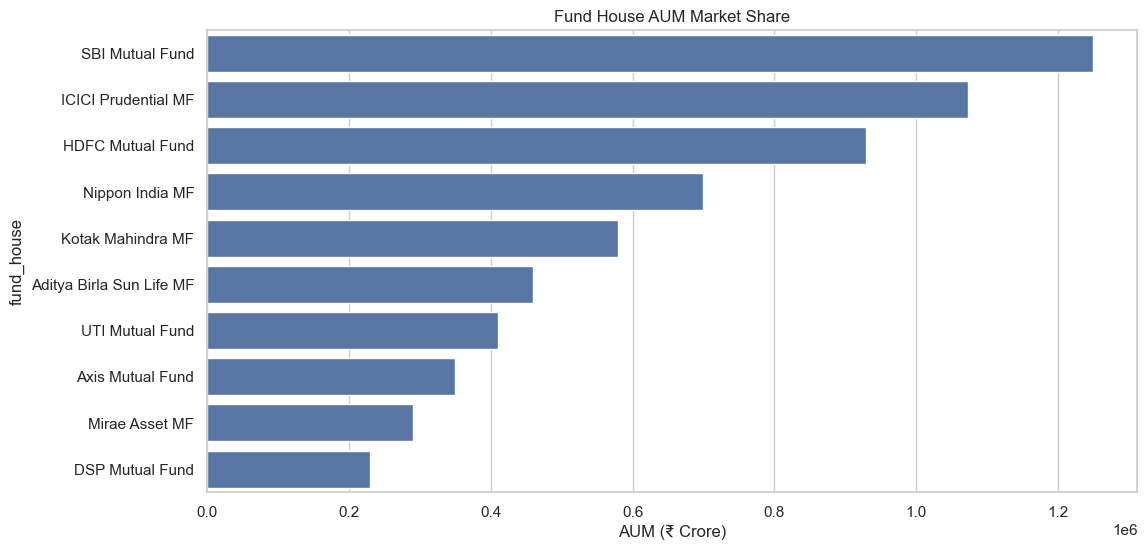

In [ ]:
#1. AUM Market Share (better than simple bar chart)
latest_aum = (
    aum.sort_values("date")
       .groupby("fund_house")
       .tail(1)
       .sort_values("aum_crore", ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=latest_aum,
    x="aum_crore",
    y="fund_house"
)

plt.title("Fund House AUM Market Share")
plt.xlabel("AUM (₹ Crore)")
plt.show()

### Insight

SBI Mutual Fund maintained the highest AUM throughout the period, indicating strong brand trust and sustained investor confidence.

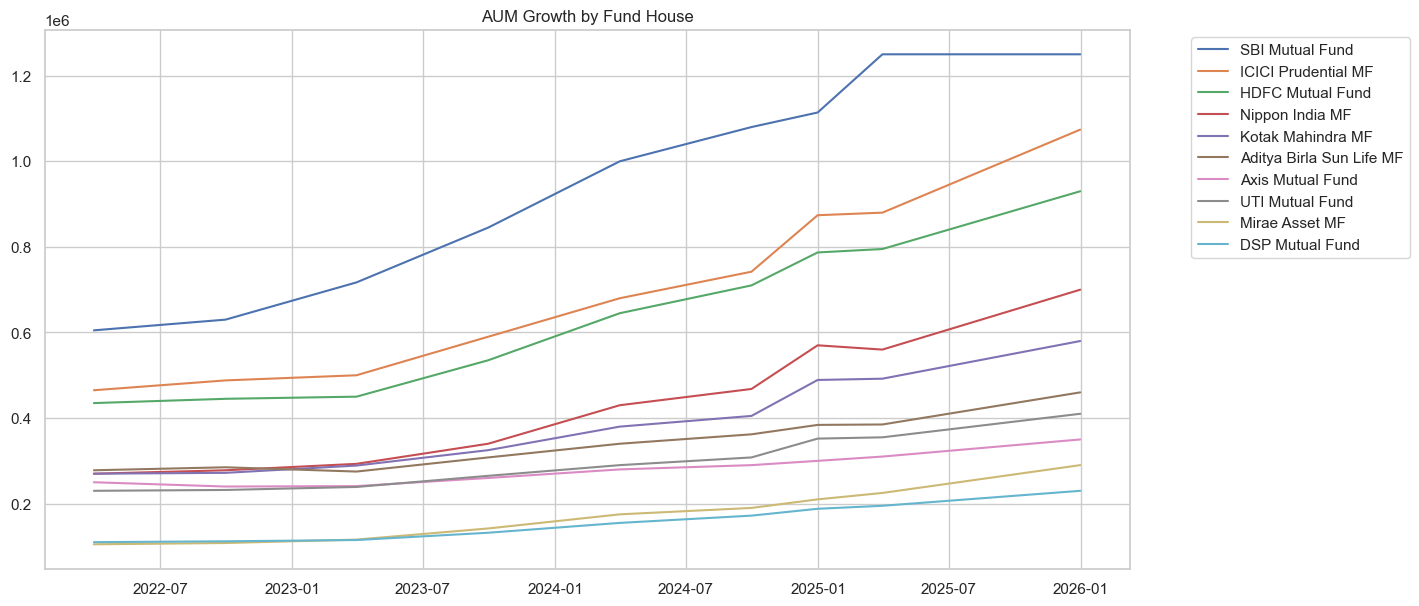

In [ ]:
#2. AUM Growth Over Time
aum["date"] = pd.to_datetime(aum["date"])

plt.figure(figsize=(14,7))

for fund in aum["fund_house"].unique():
    temp = aum[aum["fund_house"] == fund]
    plt.plot(temp["date"], temp["aum_crore"], label=fund)

plt.title("AUM Growth by Fund House")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

In [ ]:
#3. SIP Growth Trend
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows"
)

fig.show()

In [ ]:
#4. Active SIP Accounts Trend
fig = px.line(
    sip,
    x="month",
    y="active_sip_accounts_crore",
    title="Growth in Active SIP Accounts"
)

fig.show()

### Insight

SIP inflows demonstrated consistent upward momentum, reflecting growing retail participation and long-term investment discipline.

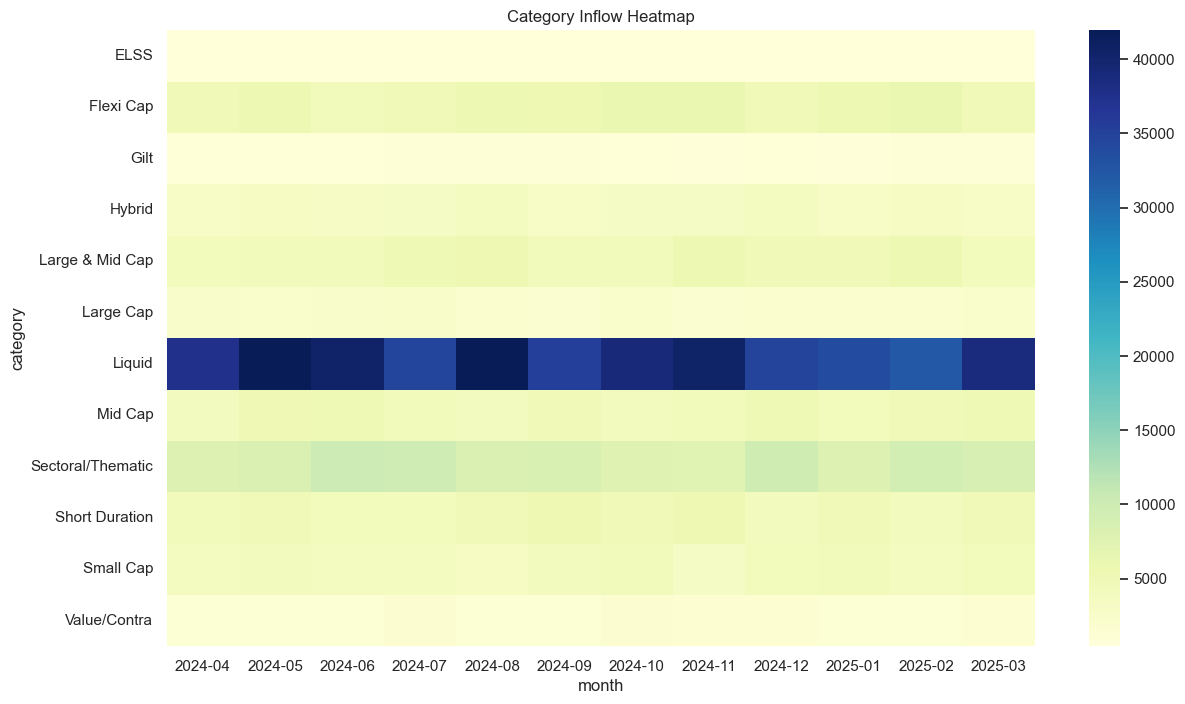

In [ ]:
#5. Category Heatmap
category_pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    category_pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.show()

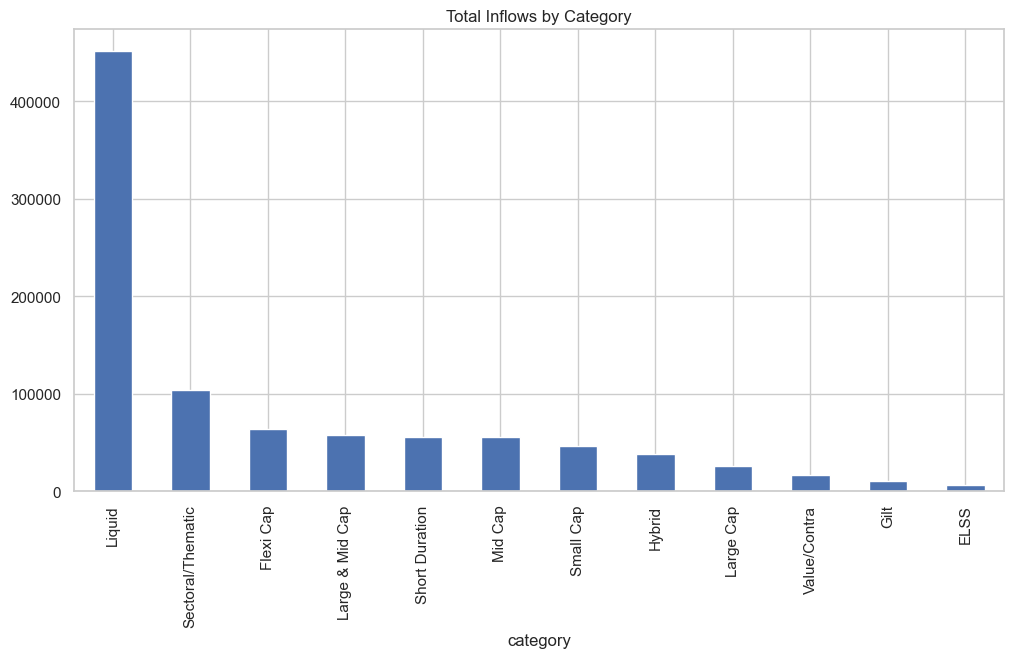

In [ ]:
#6. Category Ranking
category_rank = (
    category.groupby("category")
            ["net_inflow_crore"]
            .sum()
            .sort_values(ascending=False)
)

category_rank.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Total Inflows by Category")
plt.show()

### Insight

Equity-oriented categories attracted the highest net inflows, suggesting continued preference for growth-oriented investment products.

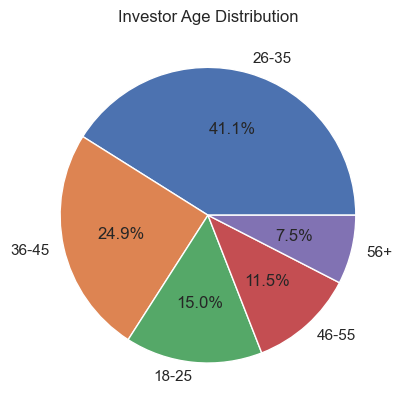

In [ ]:
#7. Investor Age Distribution
investors["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")
plt.show()

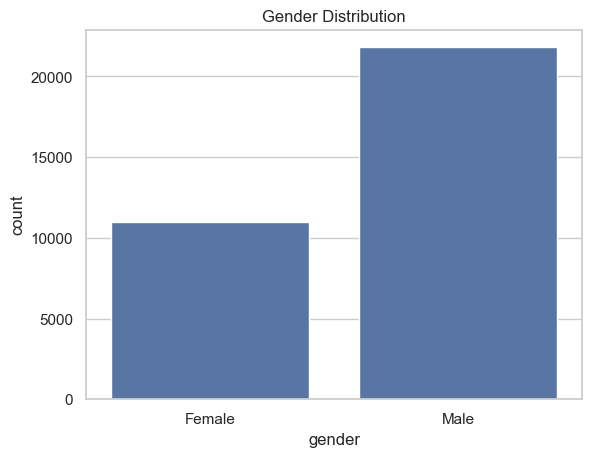

In [ ]:
#8. Gender Split
sns.countplot(
    data=investors,
    x="gender"
)

plt.title("Gender Distribution")
plt.show()

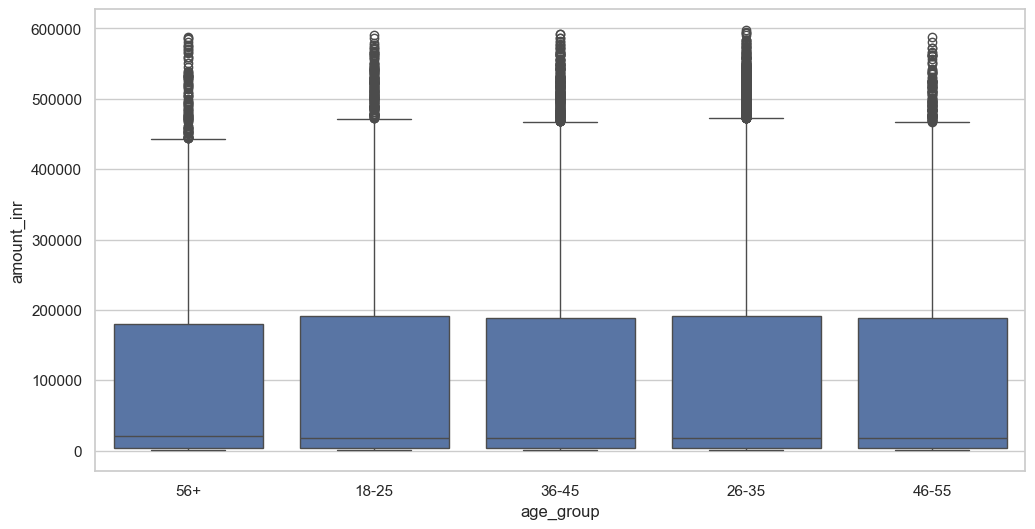

In [ ]:
#9. SIP Amount by Age Group
plt.figure(figsize=(12,6))

sns.boxplot(
    data=investors,
    x="age_group",
    y="amount_inr"
)

plt.show()

### Insight

The majority of investments originated from working-age investors, highlighting the importance of income-earning segments in mutual fund adoption.

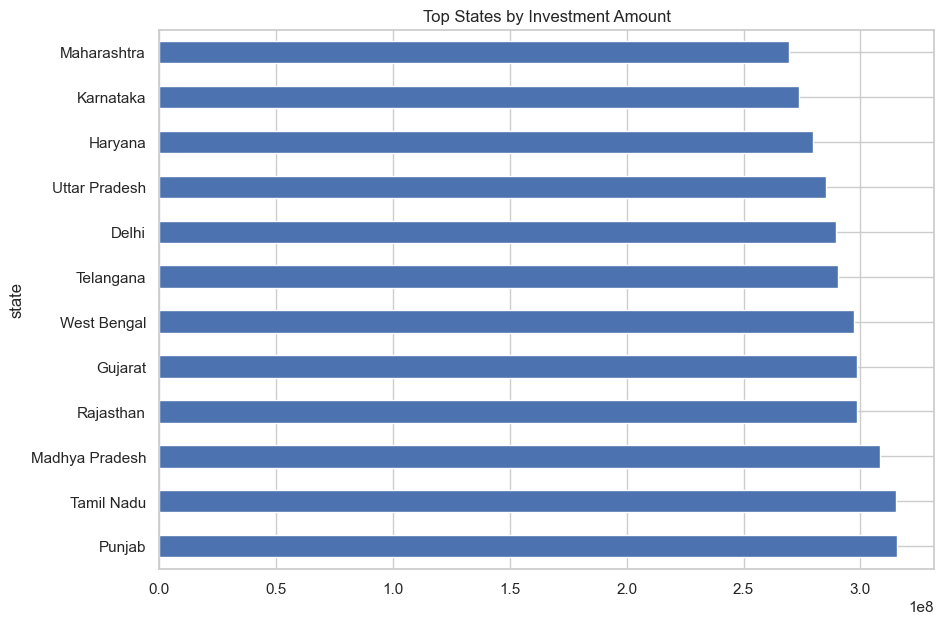

In [14]:
#10. State-wise Investment
state_amt = (
    investors.groupby("state")
             ["amount_inr"]
             .sum()
             .sort_values(ascending=False)
             .head(15)
)

state_amt.plot(
    kind="barh",
    figsize=(10,7)
)

plt.title("Top States by Investment Amount")
plt.show()

### Insight

Investment activity remains concentrated in major states and urban centers, though participation from smaller cities is steadily increasing.

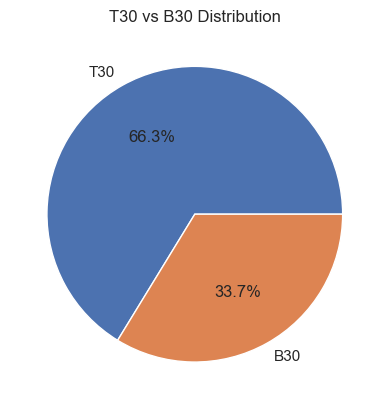

In [ ]:
#11. T30 vs B30
investors["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.show()

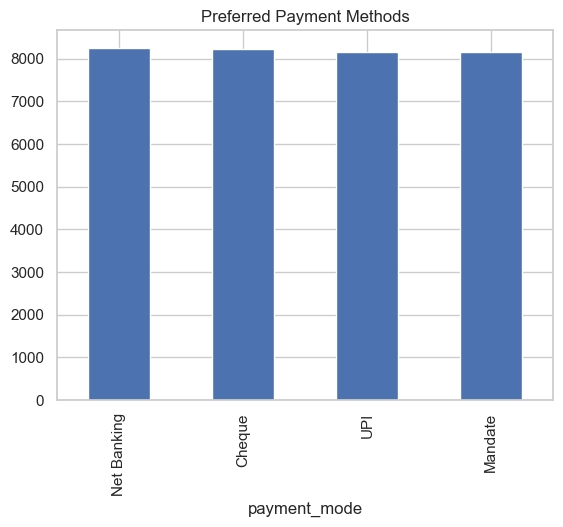

In [ ]:
#12. Payment Mode Analysis
investors["payment_mode"].value_counts().plot(
    kind="bar"
)

plt.title("Preferred Payment Methods")
plt.show()

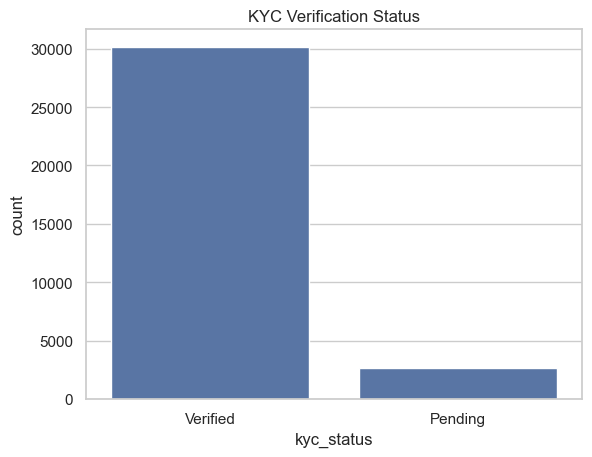

In [ ]:
#13. KYC Status Analysis
sns.countplot(
    data=investors,
    x="kyc_status"
)

plt.title("KYC Verification Status")
plt.show()

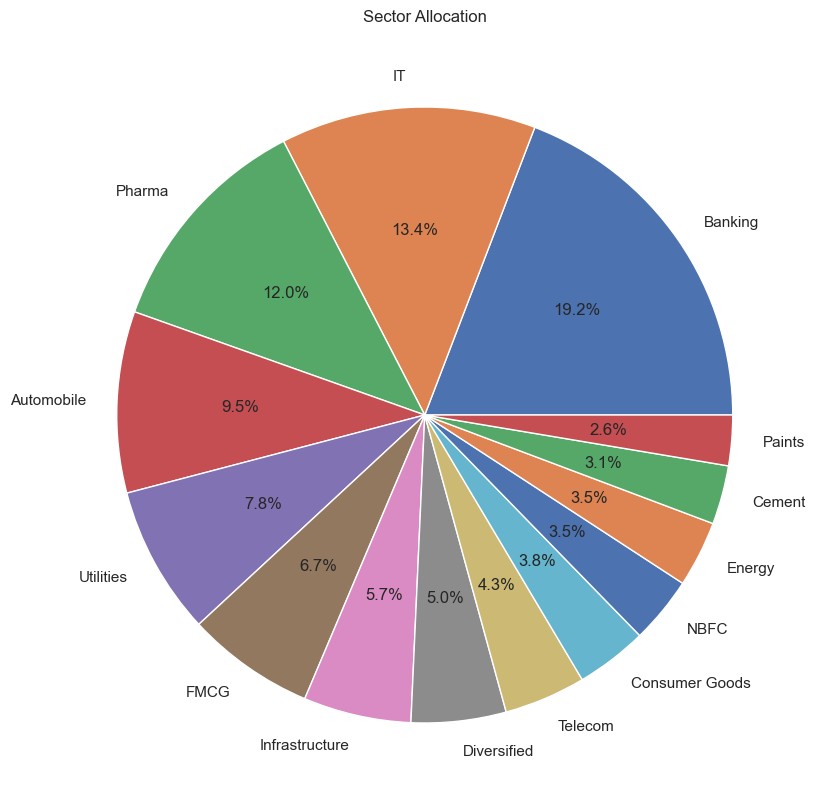

In [ ]:
#14. Sector Allocation
sector = (
    holdings.groupby("sector")
            ["weight_pct"]
            .sum()
            .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

plt.title("Sector Allocation")
plt.show()

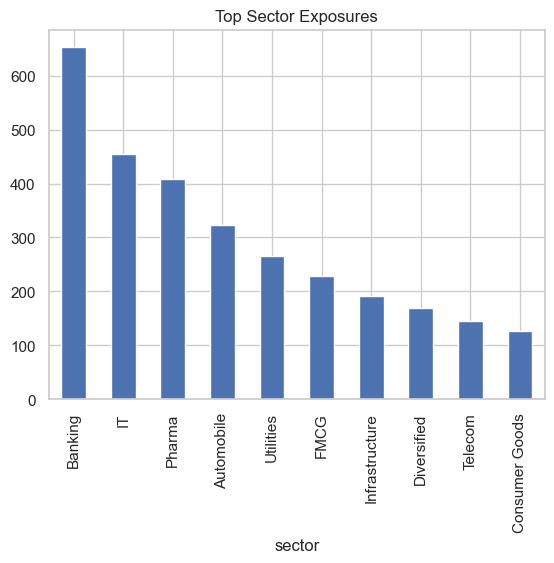

In [ ]:
#15. Sector Concentration
sector.head(10).plot(
    kind="bar"
)

plt.title("Top Sector Exposures")
plt.show()

### Insight

Portfolio allocations exhibit sector concentration, suggesting that fund performance may be sensitive to sector-specific economic trends.

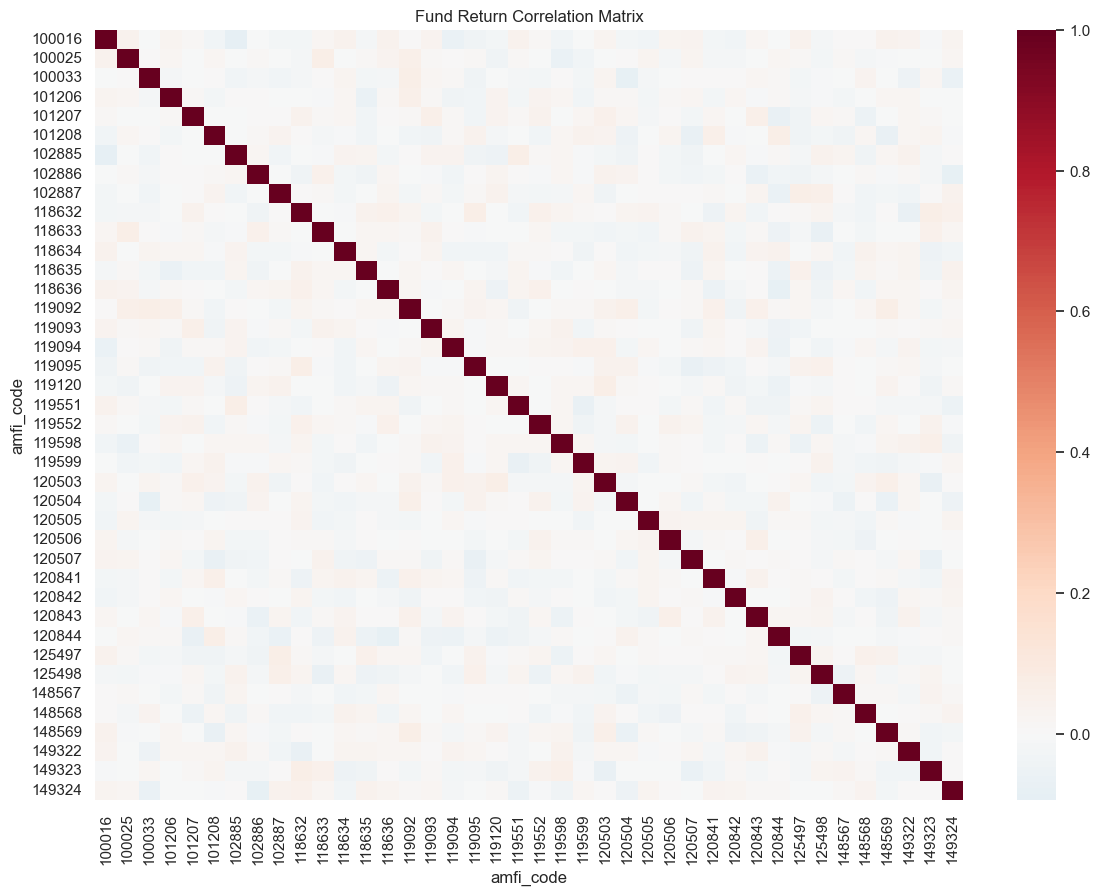

In [ ]:
#16. Correlation Matrix (high-value chart)
returns_matrix = (
    nav.pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
    .pct_change()
)

plt.figure(figsize=(14,10))

sns.heatmap(
    returns_matrix.corr(),
    cmap="RdBu_r",
    center=0
)

plt.title("Fund Return Correlation Matrix")
plt.show()

### Insight

Most large-cap funds move closely together, indicating similar market exposure and reduced diversification benefits among comparable schemes.

# Executive Summary & Key Findings

## Key Findings

### 1. Strong Industry Expansion

The Indian mutual fund industry demonstrated significant growth between 2022 and 2025, supported by increasing retail participation and rising SIP contributions.

### 2. SBI Mutual Fund Leadership

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), highlighting strong investor confidence and market leadership.

### 3. Record SIP Participation

Monthly SIP inflows reached all-time highs by the end of 2025, reflecting disciplined retail investing behavior.

### 4. Growth in Active SIP Accounts

The number of active SIP accounts increased steadily throughout the analysis period, indicating expanding investor participation.

### 5. Category Concentration

A limited number of equity-oriented categories accounted for the majority of industry inflows, suggesting strong investor preference toward growth-focused investment strategies.

### 6. Rising Investor Base

Industry folio counts nearly doubled during the study period, demonstrating rapid adoption of mutual funds across India.

### 7. Demographic Concentration

The majority of investors belonged to economically active age groups, indicating higher participation from income-earning segments.

### 8. Geographic Concentration

Investment activity remained concentrated within major states and metropolitan regions, though participation from smaller cities continued to improve.

### 9. Sector Allocation Patterns

Portfolio holdings showed meaningful concentration in a few dominant sectors, reflecting common investment themes across equity funds.

### 10. High Fund Correlation

Several large-cap oriented schemes exhibited strong positive return correlations, indicating similar market exposure and limited diversification benefits within the same category.

## Conclusion

The analysis highlights a rapidly expanding mutual fund ecosystem characterized by increasing retail participation, strong SIP growth, rising industry assets, and continued dominance of equity-oriented investment strategies. These trends indicate increasing maturity of the Indian mutual fund market and provide a strong foundation for advanced performance analytics in subsequent stages of the project.
